In [2]:
import random
import math
import numpy as np
import copy
import matplotlib.pyplot as plt

def print_matrix(M):
    for row in M:
        row_rounded = [round(x, 2) for x in row]
        row_no_negative_zeros = [0.0 if math.isclose(x, 0.0) else x for x in row_rounded]
        print(" ".join(f"{x:.2f}" for x in row_no_negative_zeros))
    print()


def divide_row(row, k, M):
    n = len(M)
    for j in range(n):
        M[row][j] /= k


def swap_rows(row1, row2, M):
    n = len(M)
    for j in range(n):
        M[row1][j], M[row2][j] = M[row2][j], M[row1][j]


def add_scaled_row_to_another(row1, row2, k, M):
    n = len(M)
    for j in range(n):
        M[row2][j] += M[row1][j] * k


def gauss_elimination(M, pivoting = True, normalize = True):
    n = len(M)

    for j in range(n): 
        if pivoting:
            maxi, pivot_idx = 0.0, 0
            for i in range(j, n):
                if abs(M[i][j]) > maxi :
                    maxi, pivot_idx = abs(M[i][j]), i
            if pivot_idx != j: # we need to swap
                swap_rows(j, pivot_idx, M)
        if normalize:
            divide_row(j, M[j][j], M) # we want our row to have 1.0 as the element on the diagonal

        for k in range(j + 1, n):
            assert not np.isclose(M[j][j], 0)
            add_scaled_row_to_another(j, k, -M[k][j]/M[j][j], M) 


def inverse_matrix(M):
    n = len(M)
    M_res = [[0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        M_res[i][i] = 1
    
    for j in range(n):
        maxi, pivot_idx = 0.0, 0 
        for i in range(j, n):
            if abs(M[i][j]) > maxi :
                maxi, pivot_idx = abs(M[i][j]), i 

        if pivot_idx != j:
            swap_rows(j, pivot_idx, M)
            swap_rows(j, pivot_idx, M_res)

        div = M[j][j]
        divide_row(j, div, M) 
        divide_row(j, div, M_res)

        for k in range(n):
            if k != j:
                scalar = -M[k][j]
                add_scaled_row_to_another(j, k, scalar, M) 
                add_scaled_row_to_another(j, k, scalar, M_res)

    return M_res



n = 6
M1 = [[random.randint(0, 15) for _ in range(n)] for _ in range(n)]
M2 = copy.deepcopy(M1)


print()
print_matrix(M1)
print("\nAFTER GAUSS ELIMINATION:\n")
gauss_elimination(M1)
print_matrix(M1)


if np.linalg.det(np.array(M2)) != 0:
    print("\nINVERSE MATRIX\n")
    print_matrix(inverse_matrix(M2))


11.00 5.00 3.00 12.00 15.00 6.00
11.00 7.00 13.00 6.00 7.00 10.00
12.00 10.00 6.00 8.00 15.00 9.00
10.00 6.00 2.00 0.00 11.00 2.00
13.00 10.00 7.00 11.00 1.00 8.00
12.00 8.00 5.00 5.00 1.00 6.00


AFTER GAUSS ELIMINATION:

1.00 0.77 0.54 0.85 0.08 0.62
0.00 1.00 0.84 -0.78 -4.09 0.22
0.00 0.00 1.00 -0.53 0.02 0.43
0.00 0.00 0.00 1.00 -0.31 0.27
0.00 0.00 0.00 0.00 1.00 0.15
0.00 0.00 0.00 0.00 0.00 1.00


INVERSE MATRIX

0.10 0.01 -0.12 0.01 -0.13 0.24
-0.18 -0.07 0.12 0.13 0.30 -0.32
-0.05 0.13 -0.13 0.17 0.22 -0.32
0.04 -0.01 -0.05 0.02 0.17 -0.17
0.01 0.01 0.03 0.04 0.00 -0.08
0.05 -0.03 0.23 -0.36 -0.45 0.54



In [66]:
def gauss_numpy(A, pivoting = True, normalize = True):
    n = len(A)
    A = np.array(A, dtype=np.float32)
    for i in range(n):
        if pivoting or np.isclose(A[i, i], 0.0):
            pivot_idx = i + np.argmax(np.abs(A[i:, i])) if pivoting else i + np.where(~np.isclose(np.abs(A[i:, i]), 0.0))[0][0]
            if pivot_idx != i:
                A[[i, pivot_idx]] = A[[pivot_idx, i]]
        if normalize:
            A[i, :] /= A[i, i]
        for j in range(i+1, n):
            factor = A[j][i]/A[i, i]
            A[j, :] -= factor * A[i, :]
    return A

def lu_factorization(A, pivoting = True):
    n = len(A)
    P = [i for i in range(n)]
    A = np.array(A, dtype=np.float32)
    L, U = np.array([[0.0 for _ in range(n)] for _ in range(n)]), np.copy(A)
    for i in range(n):
        L[i, i] = 1.0
    for i in range(n):
        
        if pivoting or np.isclose(U[i, i], 0.0):
            if pivoting:
                pivot_idx = i + np.argmax(np.abs(U[i:, i]))
            else:
                pivot_idx = i + np.where(~np.isclose(np.abs(U[i:, i]), 0.0))[0][0]
        
            if pivot_idx != i:
                U[[i, pivot_idx]] = U[[pivot_idx, i]]
                L[[i, pivot_idx], :i] = L[[pivot_idx, i], :i]
                P[i], P[pivot_idx] = P[pivot_idx], P[i]

            assert not np.isclose(U[i, i], 0.0)

        for j in range(i+1, n):
            factor = U[j][i]/U[i, i]
            U[j, :] -= factor * U[i, :]
            L[j, i] = factor

    P = np.array(P)
    P_res = np.zeros((P.size, P.max() + 1))
    P_res[np.arange(P.size), P] = 1
    return P_res, L , U


def assert_is_close(P, L, U, A):
    A1 = np.transpose(P) @ L @ U
    diff = np.abs(A1 - A)
    return np.allclose(P @ A, L @ U), diff


def assert_l_matrix(L, tol):
    identity = np.eye(L.shape[0])
    L_tr = np.triu(L) # eliminates nonzero elements of upper diagonal part
    assert np.allclose(L_tr - identity, np.zeros_like(L), atol = tol) # checks ones on diagonal


def assert_u_matrix(U, tol, has_ones = False):
    U_tr = np.tril(U, (-1 if not has_ones else 0) )
    if has_ones:
        U_tr -= np.eye(U.shape[0])
    assert np.allclose(U_tr, 0, atol=tol)


NUM_TRIALS = 1000
n = 20

pivot_diff = []
with_error, without_error = 0, 0
for i in range(NUM_TRIALS):
    M3 = [[random.randint(0, 15) for _ in range(n)] for _ in range(n)]
    M3 = np.array(M3)
    P2, L2, U2 = lu_factorization(M3)
    P3, L3, U3 = lu_factorization(M3, False)

    for i, (Li, Ui, tol) in enumerate([[L2, U2, 2e-6], [L3, U3, 5e-3]]):
        try:
            assert_l_matrix(Li, tol)
            assert_u_matrix(Ui, tol)
        except Exception as e:
            if i == 0:
                with_error += 1
            else:
                without_error += 1

    
    pivot, no_pivot = np.max(np.abs((P2 @ M3 - L2 @ U2))), np.max(np.abs((P3 @ M3 - L3 @ U3)))
    diff_i = no_pivot/pivot
    pivot_diff.append([no_pivot, pivot, diff_i])
    

pivot_diff = np.array(pivot_diff)
M4 = [[random.random() * 15 for _ in range(n)] for _ in range(n)]

gauss = gauss_numpy(M4, True, True)
assert_u_matrix(gauss, 1e-4, has_ones = True)

print(with_error, without_error)







25 20


Lims:  [0, np.float64(95.73093095959753)]
Median no pivot: 6.357597885653377e-05
Median with pivot 2.934527360665129e-06
Max difference: 44030.0


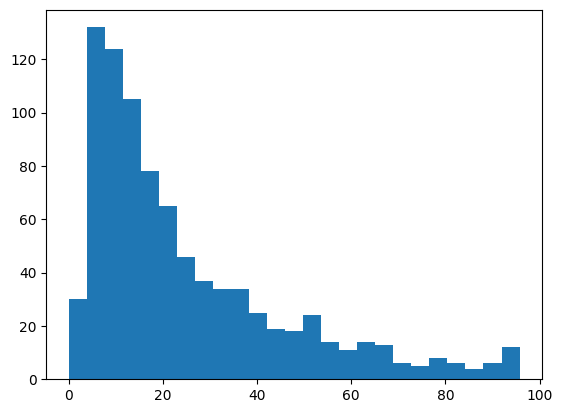

In [64]:
lims = [0, np.percentile(pivot_diff[:, 2], 87)]
k = 25
print("Lims: ", lims)
plt.hist(pivot_diff[:, 2], bins=[lims[1]/k * i for i in range(k+1)])
print("Median no pivot:", np.median(pivot_diff[:, 0]))
print("Median with pivot", np.median(pivot_diff[:, 1]))
idx_max = np.argmax(pivot_diff[:, 2])
print("Max difference:", np.round(np.max(pivot_diff[:, 2])))